# 14A — Simple OpenElections fundraising explorer (2024)

A small notebook for **meeting exploration**.

We only use a short list of finance measures:

- total amount;
- total record count;
- record count in each size bin;
- record share in each size bin.

Then we do two simple things:

1. run a correlation race for all of those X variables;
2. choose one X variable and draw one OLS regression plot.

No candidate groups are colored here. The point is to look at the raw
relationship first and decide later what "similar" means for each metric.

> Descriptive only. This does not show causation.


## 1. Setup

This notebook is self-contained for the analysis step: it reads the
candidate-level profile table already built for this source and the
ballot-support table.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display
from matplotlib.ticker import (
    PercentFormatter,
    StrMethodFormatter,
)


# ---------------------------------------------------------------
# Find the repository root
# ---------------------------------------------------------------

cwd = Path.cwd().resolve()

if (cwd / "pyproject.toml").exists():

    ROOT = cwd

elif (cwd.parent / "pyproject.toml").exists():

    ROOT = cwd.parent

else:

    raise FileNotFoundError(
        "Could not find pyproject.toml in this folder or its parent."
    )


print(
    "ROOT:",
    ROOT,
)


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis


## 2. Change only these values

`RACE_DISTRICT` controls the correlation table.

`PLOT_DISTRICT` controls the regression plot.

Use `"all"` for all four districts together, or use `1`, `2`, `3`, or `4`.

`X_METRIC` is the finance variable you want on the x-axis.

`Y_METRIC` can be `"mentions"` or `"first_place_votes"`.


In [2]:
YEAR = 2024

# Correlation race sample
RACE_DISTRICT = "all"

# Regression plot sample
PLOT_DISTRICT = 4

# Change this line to play with another finance metric
X_METRIC = "total_amount"

# Options: "mentions", "first_place_votes"
Y_METRIC = "mentions"

SHOW_NAMES = True


## 3. Load OpenElections fundraising + ballot support

This uses the OpenElections/Portland-contributions candidate profile built earlier. Public matching contributions were excluded upstream from the private-fundraising profile.


In [3]:
SUPPORT_PATH = (
    ROOT
    / "data"
    / "processed"
    / "ballot_support"
    / str(YEAR)
    / f"candidate_ballot_support_{YEAR}.csv"
)


PROFILE_PATH = (
    ROOT
    / "data/processed/fundraising/2024/city_council/openelections_candidate_fundraising_profiles_wide.csv"
)


for path in [
    SUPPORT_PATH,
    PROFILE_PATH,
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing required file: {path}"
        )


support = pd.read_csv(
    SUPPORT_PATH,
    low_memory=False,
)


profile = pd.read_csv(
    PROFILE_PATH,
    low_memory=False,
)


# Keep only profiles linked to an official candidate.
profile = profile[
    profile["candidate_key"].notna()
].copy()


# A duplicated candidate key would make the merge ambiguous.
if profile["candidate_key"].duplicated().any():

    duplicates = profile[
        profile["candidate_key"].duplicated(
            keep=False
        )
    ].copy()

    display(
        duplicates[
            [
                column
                for column in [
                    "district",
                    "candidate_key",
                    "canonical_candidate",
                    "candidate",
                ]
                if column in duplicates.columns
            ]
        ]
    )

    raise ValueError(
        "Duplicate candidate_key values found in the finance profile."
    )


print(
    "Ballot-support candidates:",
    len(support),
)

print(
    "OpenElections fundraising profiles:",
    len(profile),
)


Ballot-support candidates: 98
OpenElections fundraising profiles: 65


## The X variables


In [4]:
BINS = [
    "micro",
    "small",
    "medium",
    "large",
    "mega",
]


METRICS = [
    "total_amount",
    "total_contribution_count",
]


for bin_name in BINS:

    METRICS.append(
        f"contribution_count_{bin_name}"
    )

    METRICS.append(
        f"contribution_share_{bin_name}"
    )


METRIC_LABELS = {
    "total_amount":
        "Total private fundraising ($)",

    "total_contribution_count":
        "Contribution records",
}


for bin_name in BINS:

    nice_bin = bin_name.title()

    METRIC_LABELS[
        f"contribution_count_{bin_name}"
    ] = (
        f"{nice_bin} contribution records"
    )

    METRIC_LABELS[
        f"contribution_share_{bin_name}"
    ] = (
        f"{nice_bin} share of contribution records"
    )


missing_metrics = [
    metric
    for metric in METRICS
    if metric not in profile.columns
]


if missing_metrics:

    raise ValueError(
        "These expected metrics are missing from the profile table: "
        + str(missing_metrics)
    )


print("Available X metrics:")

for metric in METRICS:
    print(
        "-",
        metric,
        "→",
        METRIC_LABELS[metric],
    )


Available X metrics:
- total_amount → Total private fundraising ($)
- total_contribution_count → Contribution records
- contribution_count_micro → Micro contribution records
- contribution_share_micro → Micro share of contribution records
- contribution_count_small → Small contribution records
- contribution_share_small → Small share of contribution records
- contribution_count_medium → Medium contribution records
- contribution_share_medium → Medium share of contribution records
- contribution_count_large → Large contribution records
- contribution_share_large → Large share of contribution records
- contribution_count_mega → Mega contribution records
- contribution_share_mega → Mega share of contribution records


## 5. Merge finance with ballot support

Ballot support is the main candidate table. Finance variables are added
when a matching `candidate_key` is available.


In [5]:
keep_columns = [
    "year",
    "district",
    "candidate_key",
] + METRICS


analysis = (
    support
    .merge(
        profile[
            keep_columns
        ],
        on=[
            "year",
            "district",
            "candidate_key",
        ],
        how="left",
        validate="one_to_one",
    )
)


print(
    "Candidates:",
    len(analysis),
)

print(
    "Candidates with finance data:",
    analysis[
        METRICS[0]
    ].notna().sum(),
)


display(
    analysis[
        [
            "district",
            "canonical_candidate",
            "mentions",
            "first_place_votes",
        ]
        + METRICS
    ]
    .head(10)
)


Candidates: 98
Candidates with finance data: 65


,district,canonical_candidate,mentions,first_place_votes,total_amount,total_contribution_count,contribution_count_micro,contribution_share_micro,contribution_count_small,contribution_share_small,contribution_count_medium,contribution_share_medium,contribution_count_large,contribution_share_large,contribution_count_mega,contribution_share_mega
0,1,Timur Ender,16858.0,3550.0,61809.84,1260.0,840.0,0.666667,315.0,0.250000,62.0,0.049206,43.0,0.034127,0.0,0.000000
1,1,Terrence Hayes,15967.0,3975.0,36108.05,963.0,748.0,0.776739,165.0,0.171340,29.0,0.030114,21.0,0.021807,0.0,0.000000
2,1,Loretta Smith,17984.0,5586.0,43744.96,517.0,286.0,0.553191,144.0,0.278530,36.0,0.069632,51.0,0.098646,0.0,0.000000
3,1,Deian Salazar,5262.0,720.0,1380.00,54.0,41.0,0.759259,12.0,0.222222,1.0,0.018519,0.0,0.000000,0.0,0.000000
4,1,Joe Allen,4955.0,978.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,Noah Ernst,11606.0,4052.0,12993.18,416.0,337.0,0.810096,66.0,0.158654,5.0,0.012019,8.0,0.019231,0.0,0.000000
6,1,Jamie Dunphy,18470.0,5064.0,35174.53,1055.0,860.0,0.815166,151.0,0.143128,22.0,0.020853,21.0,0.019905,1.0,0.000948
7,1,Doug Clove,7593.0,1698.0,1505.00,13.0,8.0,0.615385,2.0,0.153846,1.0,0.076923,2.0,0.153846,0.0,0.000000
8,1,Peggy Sue Owens,3869.0,1266.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,Michael (Mike) Sands,5196.0,952.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Small correlation function

For every X variable we calculate:

- `n`
- Pearson `r`
- Spearman `r`

We do this for both ballot outcomes.


In [6]:
def calculate_correlations(
    data,
    metrics,
    outcomes,
):

    rows = []


    for outcome in outcomes:

        for metric in metrics:

            pair = (
                data[
                    [
                        metric,
                        outcome,
                    ]
                ]
                .dropna()
            )


            if (
                len(pair) < 3
                or pair[metric].nunique() < 2
                or pair[outcome].nunique() < 2
            ):

                continue


            rows.append(
                {
                    "outcome":
                        outcome,

                    "metric":
                        metric,

                    "n":
                        len(pair),

                    "pearson_r":
                        pair[metric].corr(
                            pair[outcome],
                            method="pearson",
                        ),

                    "spearman_r":
                        pair[metric].corr(
                            pair[outcome],
                            method="spearman",
                        ),
                }
            )


    return pd.DataFrame(
        rows
    )


## Correlation race


In [7]:
if RACE_DISTRICT == "all":

    race_data = analysis.copy()

else:

    race_data = analysis[
        analysis["district"].eq(
            RACE_DISTRICT
        )
    ].copy()


correlations = calculate_correlations(
    race_data,
    metrics=METRICS,
    outcomes=[
        "mentions",
        "first_place_votes",
    ],
)


correlations["label"] = (
    correlations["metric"]
    .map(
        METRIC_LABELS
    )
)


for outcome in [
    "mentions",
    "first_place_votes",
]:

    race = (
        correlations[
            correlations["outcome"].eq(
                outcome
            )
        ]
        .assign(
            abs_pearson=lambda data:
                data["pearson_r"].abs()
        )
        .sort_values(
            "abs_pearson",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


    race.insert(
        0,
        "rank",
        np.arange(
            1,
            len(race) + 1,
        ),
    )


    print()
    print(
        f"CORRELATION RACE — {outcome}"
    )

    print(
        "District:",
        RACE_DISTRICT,
    )


    display(
        race[
            [
                "rank",
                "metric",
                "label",
                "n",
                "pearson_r",
                "spearman_r",
            ]
        ]
        .round(
            {
                "pearson_r": 3,
                "spearman_r": 3,
            }
        )
    )



CORRELATION RACE — mentions
District: all


,rank,metric,label,n,pearson_r,spearman_r
0,1,contribution_count_small,Small contribution records,65,0.801,0.819
1,2,total_amount,Total private fundraising ($),65,0.779,0.800
2,3,total_contribution_count,Contribution records,65,0.725,0.755
3,4,contribution_count_medium,Medium contribution records,65,0.669,0.769
4,5,contribution_count_micro,Micro contribution records,65,0.620,0.666
5,6,contribution_count_large,Large contribution records,65,0.556,0.708
6,7,contribution_share_mega,Mega share of contribution records,65,0.257,0.290
7,8,contribution_count_mega,Mega contribution records,65,0.227,0.287
8,9,contribution_share_small,Small share of contribution records,65,0.163,0.203
9,10,contribution_share_micro,Micro share of contribution records,65,-0.079,-0.132



CORRELATION RACE — first_place_votes
District: all


,rank,metric,label,n,pearson_r,spearman_r
0,1,contribution_count_small,Small contribution records,65,0.780,0.773
1,2,total_amount,Total private fundraising ($),65,0.752,0.764
2,3,contribution_count_medium,Medium contribution records,65,0.682,0.728
3,4,total_contribution_count,Contribution records,65,0.679,0.714
4,5,contribution_count_micro,Micro contribution records,65,0.568,0.621
5,6,contribution_count_large,Large contribution records,65,0.516,0.692
6,7,contribution_share_mega,Mega share of contribution records,65,0.290,0.341
7,8,contribution_count_mega,Mega contribution records,65,0.259,0.340
8,9,contribution_share_small,Small share of contribution records,65,0.187,0.209
9,10,contribution_share_micro,Micro share of contribution records,65,-0.115,-0.166


## Regression plot


```python
X_METRIC = "..."
PLOT_DISTRICT = ...
Y_METRIC = "..."
```

In [8]:
def add_candidate_labels(
    ax,
    data,
    x_column,
    y_column,
):
    # A small set of different label positions.
    # We cycle through them so labels do not all sit
    # in exactly the same place relative to the point.

    offsets = [
        (6, 8),
        (6, -12),
        (-6, 8),
        (-6, -12),
        (12, 16),
        (12, -20),
        (-12, 16),
        (-12, -20),
        (18, 2),
        (-18, 2),
        (0, 22),
        (0, -26),
    ]


    ordered = (
        data
        .sort_values(
            [
                x_column,
                y_column,
            ]
        )
        .reset_index(
            drop=True
        )
    )


    for i, row in ordered.iterrows():

        x_offset, y_offset = (
            offsets[
                i % len(offsets)
            ]
        )


        ax.annotate(
            str(
                row[
                    "canonical_candidate"
                ]
            ),
            (
                row[x_column],
                row[y_column],
            ),
            xytext=(
                x_offset,
                y_offset,
            ),
            textcoords="offset points",
            fontsize=8,
            ha=(
                "left"
                if x_offset >= 0
                else "right"
            ),
            va="center",
        )


In [ ]:
def plot_simple_regression(
    data,
    x_column,
    y_column,
    district="all",
    show_names=True,
):

    if x_column not in METRICS:

        raise ValueError(
            "X_METRIC is not in METRICS. "
            "Look at the printed metric list above."
        )


    if y_column not in [
        "mentions",
        "first_place_votes",
    ]:

        raise ValueError(
            "Y_METRIC must be 'mentions' "
            "or 'first_place_votes'."
        )


    if district == "all":

        plot_data = data.copy()

    else:

        plot_data = data[
            data["district"].eq(
                district
            )
        ].copy()


    plot_data = (
        plot_data[
            [
                "canonical_candidate",
                x_column,
                y_column,
            ]
        ]
        .dropna()
        .copy()
    )


    if len(plot_data) < 3:

        raise ValueError(
            "Not enough complete observations for this regression."
        )


    # -----------------------------------------------------------
    # OLS
    # -----------------------------------------------------------

    x = plot_data[
        x_column
    ].astype(float).to_numpy()

    y = plot_data[
        y_column
    ].astype(float).to_numpy()


    X = sm.add_constant(
        x
    )

    model = sm.OLS(
        y,
        X,
    ).fit()


    x_plot = np.linspace(
        x.min(),
        x.max(),
        300,
    )


    X_plot = sm.add_constant(
        x_plot
    )


    prediction = (
        model
        .get_prediction(
            X_plot
        )
        .summary_frame(
            alpha=0.05
        )
    )


    # -----------------------------------------------------------
    # Plot
    # -----------------------------------------------------------

    figure_height = max(
        7,
        6 + len(plot_data) * 0.08,
    )


    fig, ax = plt.subplots(
        figsize=(
            12,
            figure_height,
        )
    )


    ax.scatter(
        x,
        y,
        alpha=0.75,
    )


    ax.plot(
        x_plot,
        prediction[
            "mean"
        ],
        label="OLS fit",
    )


    ax.fill_between(
        x_plot,
        prediction[
            "mean_ci_lower"
        ],
        prediction[
            "mean_ci_upper"
        ],
        alpha=0.15,
        label="95% CI",
    )


    if show_names:

        add_candidate_labels(
            ax,
            plot_data,
            x_column,
            y_column,
        )


    # -----------------------------------------------------------
    #  axis formatting
    # -----------------------------------------------------------

    ax.set_xlabel(
        METRIC_LABELS[
            x_column
        ]
    )

    ax.set_ylabel(
        (
            "Ballot mentions"
            if y_column == "mentions"
            else "First-place votes"
        )
    )


    if "share" in x_column:

        ax.xaxis.set_major_formatter(
            PercentFormatter(
                1.0
            )
        )

    elif (
        x_column == METRICS[0]
    ):

        ax.xaxis.set_major_formatter(
            StrMethodFormatter(
                "${x:,.0f}"
            )
        )

    else:

        ax.xaxis.set_major_formatter(
            StrMethodFormatter(
                "{x:,.0f}"
            )
        )


    ax.yaxis.set_major_formatter(
        StrMethodFormatter(
            "{x:,.0f}"
        )
    )


    pearson_r = (
        plot_data[
            x_column
        ]
        .corr(
            plot_data[
                y_column
            ],
            method="pearson",
        )
    )


    ax.set_title(
        (
            f"{METRIC_LABELS[x_column]} → "
            f"{y_column.replace('_', ' ')}\n"
            f"District: {district} | "
            f"Pearson r = {pearson_r:.2f} | "
            f"R² = {model.rsquared:.2f} | "
            f"n = {len(plot_data)}"
        )
    )


    ax.margins(
        x=0.12,
        y=0.12,
    )

    ax.legend(
        frameon=False
    )

    plt.tight_layout()
    plt.show()


    results = pd.DataFrame(
        {
            "x_metric": [
                x_column
            ],
            "y_metric": [
                y_column
            ],
            "district": [
                district
            ],
            "n": [
                len(plot_data)
            ],
            "slope": [
                model.params[1]
            ],
            "intercept": [
                model.params[0]
            ],
            "pearson_r": [
                pearson_r
            ],
            "r_squared": [
                model.rsquared
            ],
        }
    )


    display(
        results.round(
            3
        )
    )


    return model


## 9. Run the selected regression

Change the configuration at the top and rerun this cell.


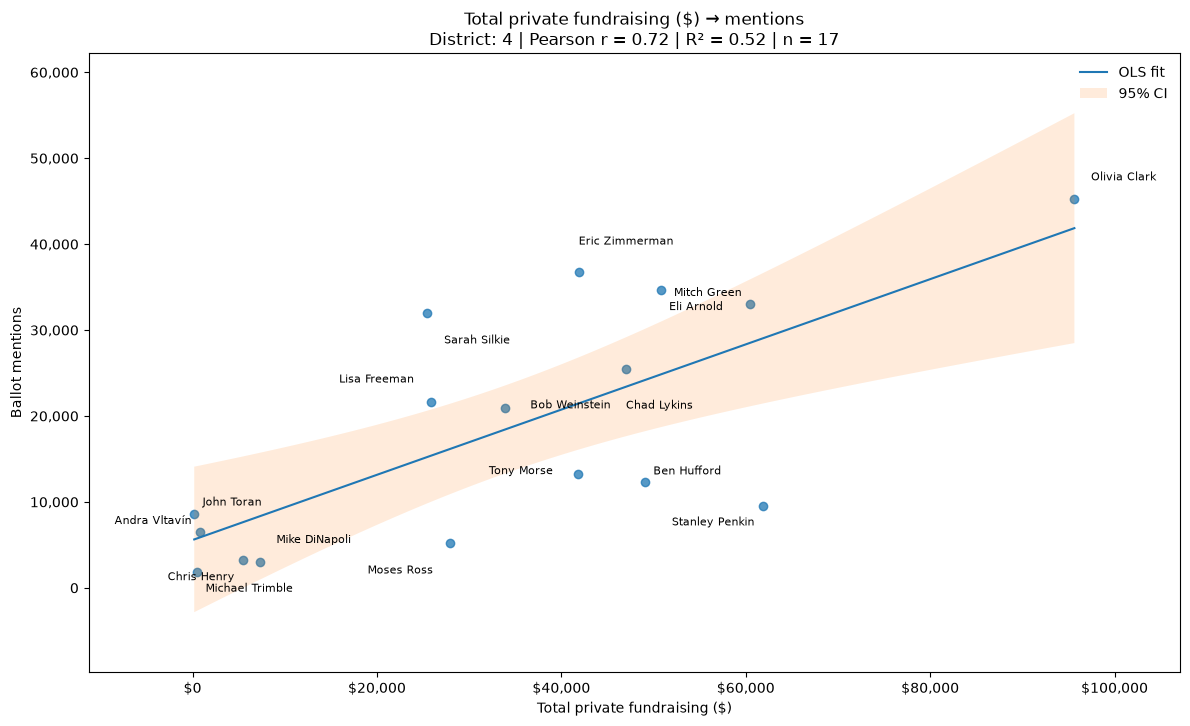

,x_metric,y_metric,district,n,slope,intercept,pearson_r,r_squared
0,total_amount,mentions,4,17,0.38,5567.555,0.722,0.522


In [10]:
model = plot_simple_regression(
    analysis,
    x_column=X_METRIC,
    y_column=Y_METRIC,
    district=PLOT_DISTRICT,
    show_names=SHOW_NAMES,
)
